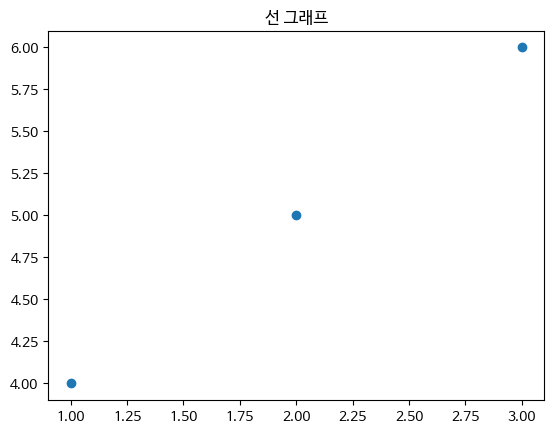

In [68]:
import gdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm


url = r'c:\Windows\Fonts\NanumBarunGothic.ttf'
fm.fontManager.addfont(url)
plt.rc('font', family = fm.FontProperties(fname=url).get_name())

plt.scatter([1, 2, 3], [4, 5, 6])
plt.title('선 그래프')
plt.show()



In [2]:
#Z점수 구하기: 서로 다른 단위의 모집단 데이터 간의 분산 정도 구하기
from scipy import stats
x = [0, 3, 5, 7, 10]

#사이파이 zscore
stats.zscore(x)

#scipy zscore 비율
stats.norm.cdf(1.5) - stats.norm.cdf(-1.5)


#scipy 비율의 zscore
stats.norm.ppf(0.999999)

np.float64(4.753424308817087)

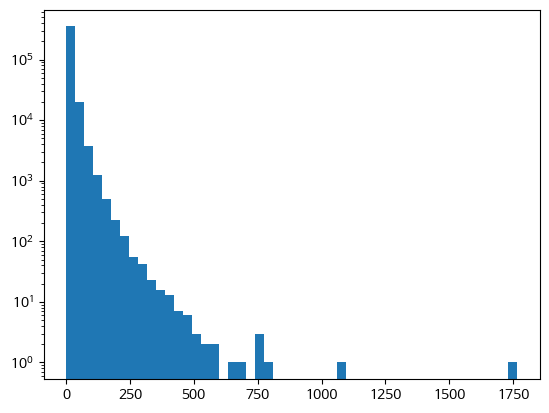

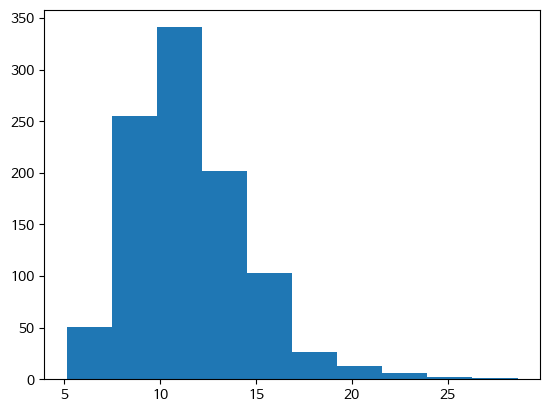

In [3]:
ns_book7 = pd.read_csv(r'C:\data\ns_book7.csv', low_memory=False)

plt.hist(ns_book7['대출건수'], bins=50)
plt.yscale('log')
plt.show()

sample_mean_list = []
np.random.seed(42)
for _ in range(1000):
    s = ns_book7['대출건수'].sample(40).mean()
    sample_mean_list.append(s)
df = pd.Series(sample_mean_list)

plt.hist(df)
plt.show()


In [69]:
n = ns_book7['주제분류번호'].astype('string').str.strip()
t = ns_book7['도서명'].astype('string').str.strip()
python_books_index = n.str.startswith('00', na=False) \
& t.str.contains('파이썬', na=False)



#모평균 추정 신뢰도:95%
py_books = ns_book7[python_books_index]
py_mean = np.mean(py_books['대출건수'])
py_se = np.std(py_books['대출건수']) / np.sqrt(len(py_books))
z = stats.norm.ppf(0.975)
print(py_mean-z*py_se, py_mean+z*py_se)


# py_books = ns_book7[python_books_index]
# py_mean = np.mean(py_books['대출건수'])
# py_std = np.std(py_books['대출건수'])
# py_se = py_std / np.sqrt(len(py_books))
# z2 = stats.norm.ppf(0.975)
# z1 = stats.norm.ppf(0.025)  
# print(py_mean + z1*py_se, py_mean + z2*py_se) #모평균이 12.9에서 16 사이에 있을 거라 95%로 확신한다.

#모평균 가설검정 신뢰도 : 95%, 귀무가설: p책과 c책의 모평균은 같다. 대립가설 모평균은 같지 않다
c_book_index = ns_book7['주제분류번호'].astype('string').str.strip().str.startswith('00', na=False) \
    & ns_book7['도서명'].astype('string').str.strip().str.contains('c++', regex=False, case=False, na = False)
c_books = ns_book7[c_book_index]

c_mean = np.mean(c_books['대출건수'])
c_std = np.std(c_books['대출건수'])
c_se = c_std / np.sqrt(len(c_books))

z = (py_mean - c_mean) / np.sqrt(py_se**2 + c_se**2)
z
stats.norm.cdf(z) 




13.172876980103716 16.325130988023773


np.float64(0.9937093846782195)

In [ ]:
#모수 검정 t-test: 파이썬 교재와 c++ 교재의 대출건수(수요층)는 같은 집단인가 귀무가설: 같다, 대립가설: 파이썬 평균 > C교재 평균
t = stats.ttest_ind(py_books['대출건수'], c_books['대출건수'])
print(t.statistic, t.pvalue)
print(np.mean(py_books['대출건수']), np.mean(c_books['대출건수']))

#비모수검정(순차검정 permutation) 
p = stats.permutation_test((py_books['대출건수'], c_books['대출건수']), lambda x, y: np.mean(x)-np.mean(y))
print(p.statistic, p.pvalue)

def permutation(x, y):
    p_statistic = np.mean(x) - np.mean(y)
    sample_list = np.append(x, y)
    diffs_list = []
    for _ in range(1000):
        idx = np.random.permutation(len(sample_list))
        x_ = sample_list[idx[:len(x)]]
        y_ = sample_list[idx[len(x):]]
        diffs_list.append(np.mean(x_)-np.mean(y_))
    pvalue_less = np.sum(diffs_list<p_statistic) / 1000
    pvalue_greater = np.sum(diffs_list>p_statistic) / 1000
    return p_statistic, np.minimum(pvalue_less, pvalue_greater)*2

permutation(py_books['대출건수'], c_books['대출건수'])


2.1390005694958574 0.033151795202247876
14.749003984063744 11.595505617977528
3.1534983660862164 0.0264


(np.float64(3.1534983660862164), np.float64(0.024))

In [82]:
jav_idx = ns_book7['주제분류번호'].astype('string').str.strip().str.startswith('00', na=False) \
    & ns_book7['도서명'].astype('string').str.strip().str.contains('자바스크립트', na=False)
print(jav_idx.sum())
jav_books = ns_book7[jav_idx]

print(len(jav_books), np.mean(jav_books['대출건수']))

res = stats.permutation_test((py_books['대출건수'], jav_books['대출건수']), statistic)
print(res.statistic, res.pvalue) #-1.9468710089399757 0.126


105
105 15.533333333333333
-0.7843293492695889 0.587
